In [1]:
import os
import csv
import matplotlib.pyplot as plt
import matplotlib as mpl
import numpy as np
from datetime import datetime

%matplotlib notebook
%matplotlib inline
mpl.use('Agg')  # Use non-interactive backend
plt.rcParams['text.usetex'] = True
plt.rcParams['font.family'] = 'serif'
plt.rcParams['font.serif'] = ['Computer Modern']
plt.rcParams['font.size'] = 20

laser_color = np.array([183, 86, 89])/255
laser_color_saturated = np.array([184,0,6])/255
mic_color = np.array([214, 174, 114])/255

In [2]:
def read_data(data_directory, file_name, downsampling=1):
    data = []
    time_axis = []
    timestamps = []
    i = 0
    first = True
    with open(os.path.join(data_directory, file_name), 'r', newline='') as csv_file:
        csv_reader = csv.reader(csv_file, delimiter=';')
        header = next(csv_reader)
        for row in csv_reader:
            timestamps.append(row[0])
            
            timestamp = datetime.strptime(row[0], '%Y-%m-%d %H:%M:%S.%f')
            if first:
                first_timestamp = timestamp
            if not first:
                time_axis += list(np.linspace((prev_timestamp - first_timestamp).total_seconds(),
                                              (timestamp - first_timestamp).total_seconds(), len(row) - 1, endpoint=False))
            i += 1
            data.append(np.array(row[1:]).astype('float'))
            prev_timestamp = timestamp
            first = False
        print(i)
    print(header)
    data = np.array(data[:-1]).reshape((1, np.size(data[:-1]))).flatten()  # reject last data row because no timestamps are estimated for it
    print(f'Original data shape: {data.shape}')
    data_downsampled = data[::downsampling]
    print(f'Downsampled data shape: {data_downsampled.shape}')
    return data_downsampled, header, timestamps, time_axis

In [3]:
a = [1, 2, 3]
print(a[:-1])

[1, 2]


In [4]:
def get_time_data(data, fs, view_range, x_time=True):
    time_axis_offset = 0
    if view_range:
        data = data[view_range[0]:view_range[1]]
    else:
        view_range = (0, data.size)
        print(f'No view range passed, using {view_range}')
    data_ac = data - np.mean(data)

    if x_time:
        time_axis = [(view_range[0] + i) / fs for i in range(len(data))]
        return time_axis, data
    else:
        time_axis = [view_range[0] + i for i in range(len(data))]
        return time_axis, data
    
def plot_data(data, fs, view_range, x_time=True):
    time_axis, data = get_time_data(data, fs, view_range, x_time=True)
    plt.plot(time_axis, data)
    if x_time:
        plt.xlabel("time [s]")
    else:
        plt.xlabel("sample")
    plt.ylabel("[V]")

In [5]:
def get_fft_data(data, fs, fft_range, view_range):
    if fft_range:
        fft_range[1] = min(fft_range[1], len(data))
        data = data[fft_range[0]:fft_range[1]]
    data_ac = data - np.mean(data)
    # print(f'data size: {data_ac.shape}')
    data_fft = np.abs(np.fft.fft(data_ac))
    # print(f'fft size: {data_fft.shape}')

    num_samples = data_fft.size
    if view_range:
        data_fft = data_fft[round(view_range[0] / fs * num_samples):
                            round(min(view_range[1], fs) / fs * num_samples)]
        freq = np.linspace(view_range[0], min(view_range[1], fs), data_fft.size)
        return freq, data_fft
    else:
        freq = np.linspace(0, fs, data_fft.size)
        return freq, data_fft
    
def plot_fft(data, fs, fft_range, view_range):
    freq, data_fft = get_fft_data(data, fs, fft_range, view_range)
    plt.plot(freq, data_fft)
    plt.xlabel("f [Hz]")
    plt.ylabel("FFT")

# External Noise

<IPython.core.display.Javascript object>


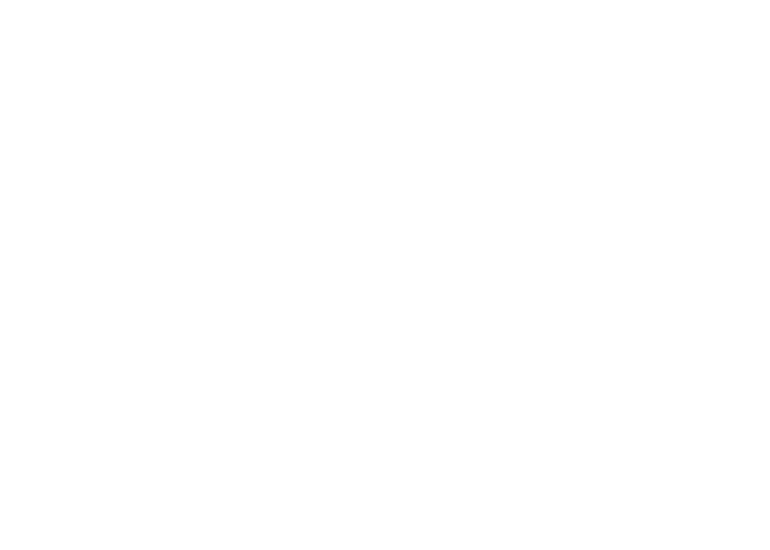

FileNotFoundError: [Errno 2] No such file or directory: 'C:/Users/idlab403/data/LaserMic/ext_noise_laser.csv'

In [6]:
%matplotlib notebook
from matplotlib.widgets import Button, Slider

downsampling = 1

data_directory = "C:/Users/idlab403/data/LaserMic"
file_name = 'ext_noise_laser.csv'

fig = plt.figure(figsize=(7, 5), constrained_layout=True)

data, header, timestamps = read_data(data_directory, file_name, downsampling)
time1 = datetime.strptime(timestamps[0], '%Y-%m-%d %H:%M:%S.%f')
time2 = datetime.strptime(timestamps[-1], '%Y-%m-%d %H:%M:%S.%f')
time_difference = (time2 - time1).total_seconds()
fs = len(data)/time_difference / downsampling
print(f'fs: {fs}')
num_samples = 3600
rest_power = np.sum(np.array(data[100:num_samples+100])**2)/num_samples
print(f'rest_power: {rest_power}')

time_axis, data = get_time_data(data, fs, view_range=None)

plt.plot(time_axis[100:], data[100:])
plt.ylim([1.5, 2.5])
'''plt.legend(["500 steps/s", "1000 steps/s"])
plt.xlabel("Frequency [Hz]")
plt.ylabel("$|$FFT$|$/$\Sigma$$|$FFT$|$$^2$")
#plt.savefig('vibrometer_plot.png')  # Saves the figure as a PNG file'''
plt.show()

<IPython.core.display.Javascript object>


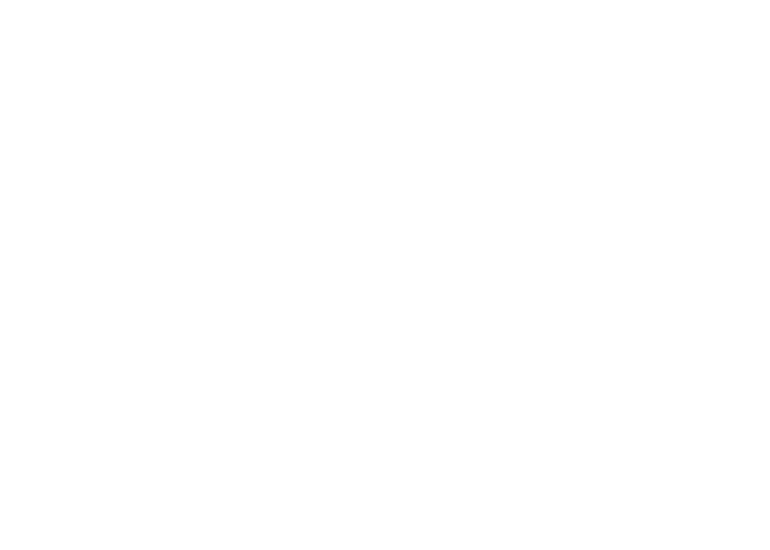

FileNotFoundError: [Errno 2] No such file or directory: '/home/idlab403/data/LaserMic/ext_noise_mic.csv'

In [9]:
%matplotlib notebook
from matplotlib.widgets import Button, Slider

downsampling = 1

#data_directory = "C:/Users/idlab403/data/LaserMic"
data_directory = "/home/idlab403/data/LaserMic"
file_name = 'ext_noise_mic.csv'

fig = plt.figure(figsize=(7, 5), constrained_layout=True)

data, header, timestamps = read_data(data_directory, file_name, downsampling)
time1 = datetime.strptime(timestamps[0], '%Y-%m-%d %H:%M:%S.%f')
time2 = datetime.strptime(timestamps[-1], '%Y-%m-%d %H:%M:%S.%f')
time_difference = (time2 - time1).total_seconds()
fs = len(data)/time_difference / downsampling
print(f'fs: {fs}')

time_axis, data = get_time_data(data, fs, view_range=None)

plt.plot(time_axis, data)
'''plt.legend(["500 steps/s", "1000 steps/s"])
plt.xlabel("Frequency [Hz]")
plt.ylabel("$|$FFT$|$/$\Sigma$$|$FFT$|$$^2$")
plt.savefig('vibrometer_plot.png')  # Saves the figure as a PNG file'''
plt.show()

# Bottle slip

<IPython.core.display.Javascript object>


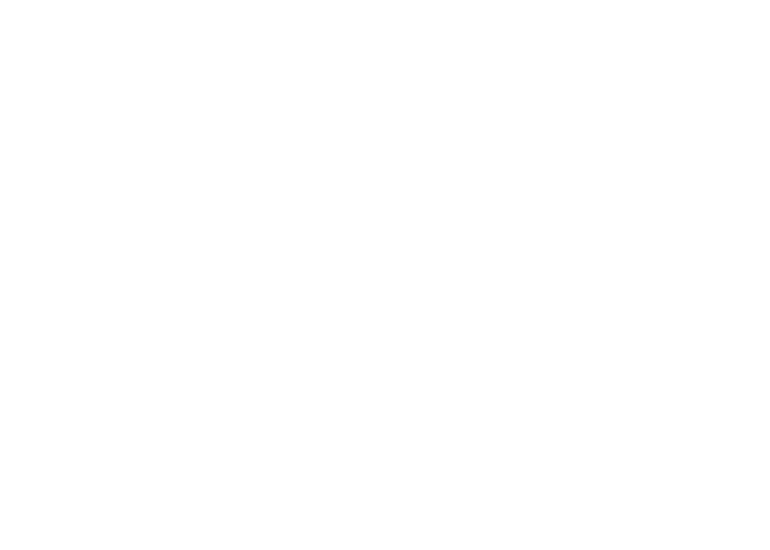

FileNotFoundError: [Errno 2] No such file or directory: '/home/idlab403/data/LaserMic/bottle_slip_laser.csv'

In [10]:
%matplotlib notebook
from matplotlib.widgets import Button, Slider

downsampling = 1

#data_directory = "C:/Users/idlab403/data/LaserMic"
data_directory = "/home/idlab403/data/LaserMic"
file_name = 'bottle_slip_laser.csv'

fig = plt.figure(figsize=(7, 5), constrained_layout=True)

data, header, timestamps, time_axis = read_data(data_directory, file_name, downsampling)
time1 = datetime.strptime(timestamps[0], '%Y-%m-%d %H:%M:%S.%f')
time2 = datetime.strptime(timestamps[-1], '%Y-%m-%d %H:%M:%S.%f')
time_difference = (time2 - time1).total_seconds()
fs = len(data)/time_difference / downsampling
print(f'fs: {fs}')

_, data = get_time_data(data, fs, view_range=None)

num_samples = 3600
rest_power = np.sum(np.array(data[100:num_samples+100])**2)/num_samples
print(f'rest_power: {rest_power}')

plt.plot(time_axis[100:], data[100:])
#plt.ylim([1.5, 2.5])
'''plt.legend(["500 steps/s", "1000 steps/s"])
plt.xlabel("Frequency [Hz]")
plt.ylabel("$|$FFT$|$/$\Sigma$$|$FFT$|$$^2$")
plt.savefig('vibrometer_plot.png')  # Saves the figure as a PNG file'''
plt.show()

<IPython.core.display.Javascript object>


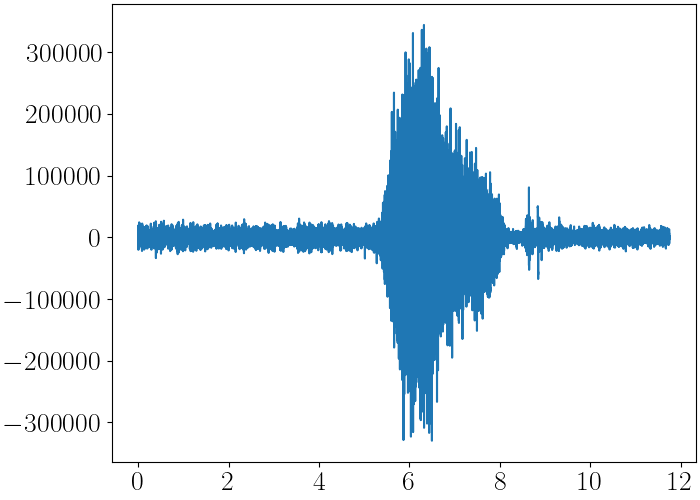

4781
['fs 3700', 'frames_per_buffer None', 'samples_per_frame 50', 'refresh_rate_hz None']
Original data shape: (239000,)
Downsampled data shape: (239000,)
fs: 20348.60307265609
No view range passed, using (0, 239000)
rest_power: 69571100.7944


In [56]:
%matplotlib notebook
from matplotlib.widgets import Button, Slider

downsampling = 1

data_directory = "C:/Users/idlab403/data/LaserMic"
file_name = 'bottle_slip_mic.csv'

fig = plt.figure(figsize=(7, 5), constrained_layout=True)

data, header, timestamps, time_axis = read_data(data_directory, file_name, downsampling)
time1 = datetime.strptime(timestamps[0], '%Y-%m-%d %H:%M:%S.%f')
time2 = datetime.strptime(timestamps[-1], '%Y-%m-%d %H:%M:%S.%f')
time_difference = (time2 - time1).total_seconds()
fs = len(data)/time_difference / downsampling
print(f'fs: {fs}')

_, data = get_time_data(data, fs, view_range=None)

num_samples = 20000
rest_power = np.sum(np.array(data[0:num_samples])**2)/num_samples
print(f'rest_power: {rest_power}')

#plt.plot(time_axis, abs(data)/np.sqrt(rest_power))
plt.plot(time_axis, data)
'''plt.legend(["500 steps/s", "1000 steps/s"])
plt.xlabel("Frequency [Hz]")
plt.ylabel("$|$FFT$|$/$\Sigma$$|$FFT$|$$^2$")
plt.savefig('vibrometer_plot.png')  # Saves the figure as a PNG file'''
plt.show()

# Pencil

<IPython.core.display.Javascript object>


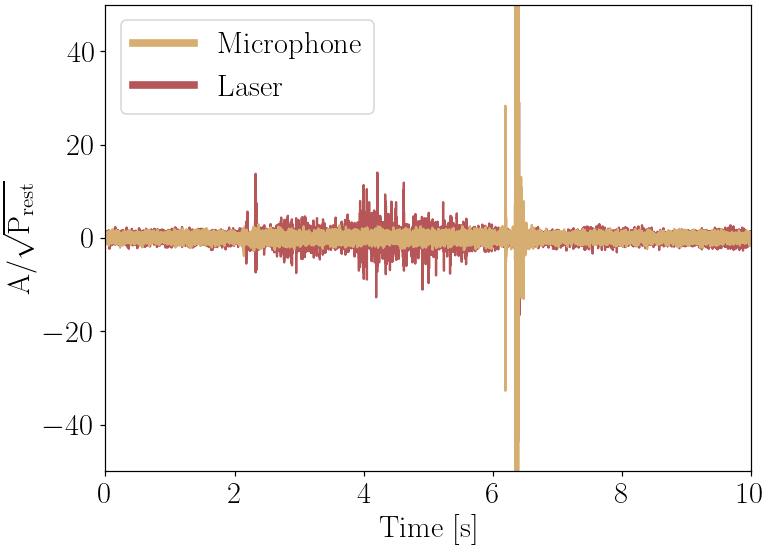

5051
['fs 3700', 'frames_per_buffer None', 'samples_per_frame 50', 'refresh_rate_hz None']
Original data shape: (252500,)
Downsampled data shape: (252500,)
fs: 19649.599011994815
MIC rest_power: 21788661.873680823 ; slip_power: 7404851.815487995 ; sensitivity: 0.5829655703222428
405
['fs 3700', 'frames_per_buffer None', 'samples_per_frame 100', 'refresh_rate_hz None']
Original data shape: (40400,)
Downsampled data shape: (40400,)
fs: 3635.7778539731225
LASER rest_power: 9.288722092257137e-05 ; slip_power: 5.549131346142982e-05 ; sensitivity: 0.7729199507467924
-------------- Laser is 1.3258415077918744 times more sensitive than mic
-------------- Mic is 0.7542379644347175 times more sensitive than laser


In [9]:
# 
#
#        External noise
#
#

%matplotlib notebook
time_axis_offset = 2

fig = plt.figure(figsize=(7, 5), constrained_layout=True)
downsampling = 1

#data_directory = "C:/Users/idlab403/data/LaserMic"
data_directory = "/home/idlab403/data/LaserMic"
file_name = 'pencil_mic_moveOnly.csv'

data, header, timestamps, time_axis = read_data(data_directory, file_name, downsampling)
mic_time_axis = np.array(time_axis) - time_axis_offset
mic_start_timestamp = datetime.strptime(timestamps[0], '%Y-%m-%d %H:%M:%S.%f')
time1 = datetime.strptime(timestamps[0], '%Y-%m-%d %H:%M:%S.%f')
time2 = datetime.strptime(timestamps[-1], '%Y-%m-%d %H:%M:%S.%f')
time_difference = (time2 - time1).total_seconds()
fs = len(data)/time_difference / downsampling
print(f'fs: {fs}')

mic_data = data - np.mean(data)
num_samples = int(4*fs)
mic_rest_power = np.sum((np.array(mic_data[:num_samples]) - np.mean(mic_data[:num_samples]))**2)/num_samples
slip_range = [170000, 220000]
mic_slip_power = np.sum((np.array(mic_data[slip_range[0]:slip_range[1]]) - np.mean(mic_data[slip_range[0]:slip_range[1]]))**2)/(slip_range[1] - slip_range[0])
power = np.sum(np.array(mic_data)**2)/len(list(mic_data))
mic_sensitivity = np.sqrt(mic_slip_power/mic_rest_power)
print(f'MIC rest_power: {mic_rest_power} ; slip_power: {mic_slip_power} ; sensitivity: {mic_sensitivity}')






downsampling = 1

#data_directory = "C:/Users/idlab403/data/LaserMic"
data_directory = "/home/idlab403/data/LaserMic"
file_name = 'pencil_laser_moveOnly.csv'

data, header, timestamps, time_axis = read_data(data_directory, file_name, downsampling)
laser_start_timestamp = datetime.strptime(timestamps[0], '%Y-%m-%d %H:%M:%S.%f')
laser_time_axis = np.array(time_axis) + (laser_start_timestamp - mic_start_timestamp).total_seconds() - time_axis_offset
time1 = datetime.strptime(timestamps[0], '%Y-%m-%d %H:%M:%S.%f')
time2 = datetime.strptime(timestamps[-1], '%Y-%m-%d %H:%M:%S.%f')
time_difference = (time2 - time1).total_seconds()
fs = len(data)/time_difference / downsampling
print(f'fs: {fs}')

laser_data = data - np.mean(data)
num_samples = int(4*fs)
laser_rest_power = np.sum((np.array(laser_data[:num_samples]) - np.mean(laser_data[:num_samples]))**2)/num_samples
slip_range = [25000, 36000]
laser_slip_power = np.sum((np.array(laser_data[slip_range[0]:slip_range[1]]) - np.mean(laser_data[slip_range[0]:slip_range[1]]))**2)/(slip_range[1] - slip_range[0])
power = np.sum(np.array(laser_data)**2)/len(list(laser_data))
laser_sensitivity = np.sqrt(laser_slip_power/laser_rest_power)
print(f'LASER rest_power: {laser_rest_power} ; slip_power: {laser_slip_power} ; sensitivity: {laser_sensitivity}')

print(f'-------------- Laser is {laser_sensitivity/mic_sensitivity} times more sensitive than mic')
print(f'-------------- Mic is {mic_sensitivity/laser_sensitivity} times more sensitive than laser')



plt.axvline(-10, linewidth=5, color=mic_color)
plt.axvline(-10, linewidth=5, color=laser_color)
plt.plot(laser_time_axis, laser_data/np.sqrt(laser_rest_power), alpha=1, color=laser_color)
plt.plot(mic_time_axis, mic_data/np.sqrt(mic_rest_power), alpha=1, color=mic_color)


plt.xlim([0, 10])
plt.ylim([-50, 50])
plt.xlabel('Time [s]')
plt.ylabel('A/$\sqrt{\mathrm{P}_{\mathrm{rest}}}$')
#plt.ylim([-12, 12])
plt.legend(["Microphone", "Laser"])
plt.show()

#plt.savefig('pencil_plot_noise.svg')

<IPython.core.display.Javascript object>


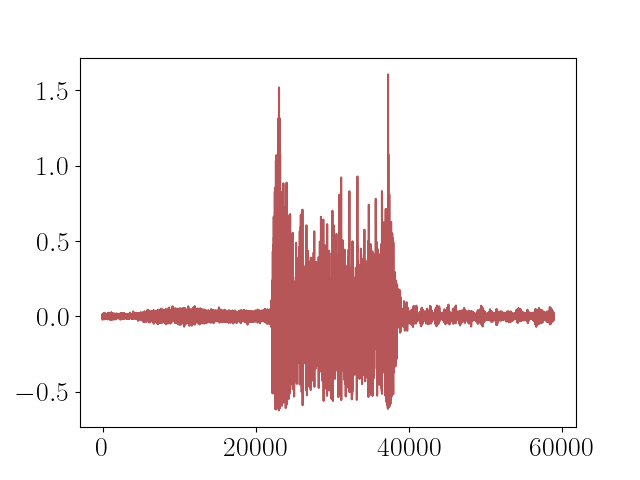

In [50]:
%matplotlib notebook
plt.plot(laser_data, alpha=1, color=laser_color)
plt.show()

<IPython.core.display.Javascript object>


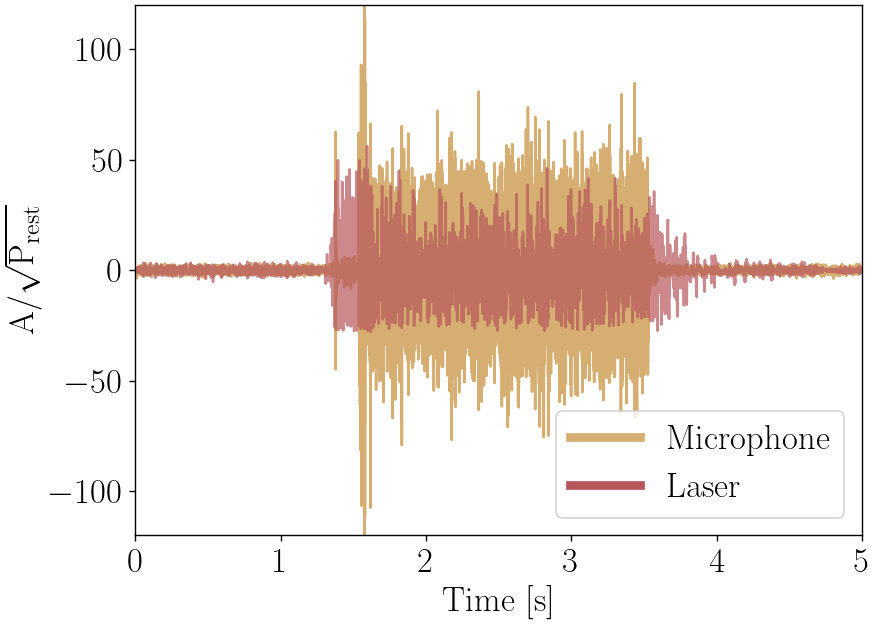

4688
['fs 3700', 'frames_per_buffer None', 'samples_per_frame 50', 'refresh_rate_hz None']
Original data shape: (234350,)
Downsampled data shape: (234350,)
fs: 20260.3544157155
MIC rest_power: 9443349.78079411 ; slip_power: 2559122172.240484 ; sensitivity: 16.461995236115513
364
['fs 3700', 'frames_per_buffer None', 'samples_per_frame 100', 'refresh_rate_hz None']
Original data shape: (36300,)
Downsampled data shape: (36300,)
fs: 3635.2631339653553
LASER rest_power: 0.0004931715228012033 ; slip_power: 0.05871437397426368 ; sensitivity: 10.911217722017685
-------------- Laser is 0.6628125913971757 times more sensitive than mic
-------------- Mic is 1.5087220927593576 times more sensitive than laser


In [65]:
# 
#
#        No external noise
#
#

%matplotlib notebook
time_axis_offset = 2

fig = plt.figure(figsize=(7, 5), constrained_layout=True)
downsampling = 1

data_directory = "C:/Users/idlab403/data/LaserMic"
file_name = 'pencil_mic.csv'

data, header, timestamps, time_axis = read_data(data_directory, file_name, downsampling)
mic_time_axis = np.array(time_axis) - time_axis_offset
mic_start_timestamp = datetime.strptime(timestamps[0], '%Y-%m-%d %H:%M:%S.%f')
time1 = datetime.strptime(timestamps[0], '%Y-%m-%d %H:%M:%S.%f')
time2 = datetime.strptime(timestamps[-1], '%Y-%m-%d %H:%M:%S.%f')
time_difference = (time2 - time1).total_seconds()
fs = len(data)/time_difference / downsampling
print(f'fs: {fs}')

mic_data = np.clip(data - np.mean(data), -40000000, 40000000)
num_samples = int(fs)
mic_rest_power = np.sum((np.array(mic_data[:num_samples]) - np.mean(mic_data[:num_samples]))**2)/num_samples
slip_range = [77000, 106000]
mic_slip_power = np.sum((np.array(mic_data[slip_range[0]:slip_range[1]]) - np.mean(mic_data[slip_range[0]:slip_range[1]]))**2)/(slip_range[1] - slip_range[0])
power = np.sum(np.array(mic_data)**2)/len(list(mic_data))
mic_sensitivity = np.sqrt(mic_slip_power/mic_rest_power)
print(f'MIC rest_power: {mic_rest_power} ; slip_power: {mic_slip_power} ; sensitivity: {mic_sensitivity}')






downsampling = 1

data_directory = "C:/Users/idlab403/data/LaserMic"
file_name = 'pencil_laser.csv'

data, header, timestamps, time_axis = read_data(data_directory, file_name, downsampling)
laser_start_timestamp = datetime.strptime(timestamps[0], '%Y-%m-%d %H:%M:%S.%f')
laser_time_axis = np.array(time_axis) + (laser_start_timestamp - mic_start_timestamp).total_seconds() - time_axis_offset
time1 = datetime.strptime(timestamps[0], '%Y-%m-%d %H:%M:%S.%f')
time2 = datetime.strptime(timestamps[-1], '%Y-%m-%d %H:%M:%S.%f')
time_difference = (time2 - time1).total_seconds()
fs = len(data)/time_difference / downsampling
print(f'fs: {fs}')

laser_data = data - np.mean(data)
num_samples = int(fs)
laser_rest_power = np.sum((np.array(laser_data[:num_samples]) - np.mean(laser_data[:num_samples]))**2)/num_samples
laser_slip_range = [9000, 14000]
laser_slip_power = np.sum((np.array(laser_data[laser_slip_range[0]:laser_slip_range[1]]) - np.mean(laser_data[laser_slip_range[0]:laser_slip_range[1]]))**2)/(laser_slip_range[1] - laser_slip_range[0])
power = np.sum(np.array(laser_data)**2)/len(list(laser_data))
laser_sensitivity = np.sqrt(laser_slip_power/laser_rest_power)
print(f'LASER rest_power: {laser_rest_power} ; slip_power: {laser_slip_power} ; sensitivity: {laser_sensitivity}')

print(f'-------------- Laser is {laser_sensitivity/mic_sensitivity} times more sensitive than mic')
print(f'-------------- Mic is {mic_sensitivity/laser_sensitivity} times more sensitive than laser')



plt.axvline(-10, linewidth=5, color=mic_color)
plt.axvline(-10, linewidth=5, color=laser_color)
plt.plot(mic_time_axis, mic_data/np.sqrt(mic_rest_power), alpha=1, color=mic_color)
plt.plot(laser_time_axis, laser_data/np.sqrt(laser_rest_power), alpha=0.7, color=laser_color)

'''plt.axvline(laser_time_axis[laser_slip_range[0]], linewidth=1, color='black')
plt.axvline(laser_time_axis[laser_slip_range[1]], linewidth=1, color='black')
plt.axvline(mic_time_axis[slip_range[0]], linewidth=1, color='black')
plt.axvline(mic_time_axis[slip_range[1]], linewidth=1, color='black')'''

plt.xlim([0, 5])
plt.xlabel('Time [s]')
plt.ylabel('A/$\sqrt{\mathrm{P}_{\mathrm{rest}}}$')
plt.ylim([-120, 120])
plt.legend(["Microphone", "Laser"])
plt.show()

#plt.savefig('pencil_plot_noNoise.svg')

<IPython.core.display.Javascript object>


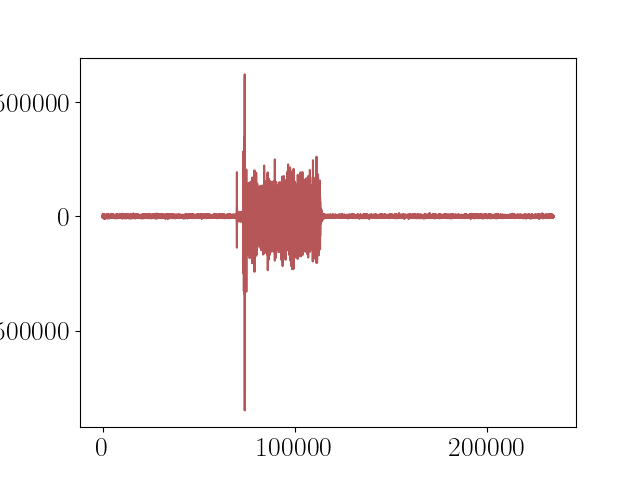

In [15]:
%matplotlib notebook
plt.plot(mic_data, alpha=1, color=laser_color)
plt.show()

In [ ]:
# 
#
#        No pencil
#
#

%matplotlib notebook


fig = plt.figure(figsize=(7, 5), constrained_layout=True)
downsampling = 1

data_directory = "C:/Users/idlab403/data/LaserMic"
file_name = 'pencil_mic_moveOnly.csv'

data, header, timestamps, time_axis = read_data(data_directory, file_name, downsampling)
mic_start_timestamp = datetime.strptime(timestamps[0], '%Y-%m-%d %H:%M:%S.%f')
time1 = datetime.strptime(timestamps[0], '%Y-%m-%d %H:%M:%S.%f')
time2 = datetime.strptime(timestamps[-1], '%Y-%m-%d %H:%M:%S.%f')
time_difference = (time2 - time1).total_seconds()
fs = len(data)/time_difference / downsampling
print(f'fs: {fs}')

data = np.clip(data - np.mean(data), -50000, 50000)
num_samples = 20000
rest_power = np.sum(np.array(data[0:num_samples])**2)/num_samples
power = np.sum(np.array(data)**2)/len(list(data))
print(f'rest_power: {rest_power}')

#plt.plot(time_axis, abs(data)/np.sqrt(rest_power))
plt.plot(time_axis, data/np.sqrt(power), alpha=1)





downsampling = 1

data_directory = "C:/Users/idlab403/data/LaserMic"
file_name = 'pencil_laser_moveOnly.csv'

data, header, timestamps, time_axis = read_data(data_directory, file_name, downsampling)
laser_start_timestamp = datetime.strptime(timestamps[0], '%Y-%m-%d %H:%M:%S.%f')
time_axis = np.array(time_axis) + (laser_start_timestamp - mic_start_timestamp).total_seconds()
time1 = datetime.strptime(timestamps[0], '%Y-%m-%d %H:%M:%S.%f')
time2 = datetime.strptime(timestamps[-1], '%Y-%m-%d %H:%M:%S.%f')
time_difference = (time2 - time1).total_seconds()
fs = len(data)/time_difference / downsampling
print(f'fs: {fs}')

data = np.clip(data - np.mean(data), -0.13, 0.13)
num_samples = 3600
rest_power = np.sum(np.array(data[100:num_samples+100])**2)/num_samples
power = np.sum(np.array(data)**2)/len(list(data))
print(f'rest_power: {rest_power}')

plt.plot(time_axis, data/np.sqrt(power), alpha=0.7)



plt.xlabel('Time [s]')
#plt.ylim([-12, 12])
plt.legend(["Microphone", "Laser"])
plt.show()



<IPython.core.display.Javascript object>


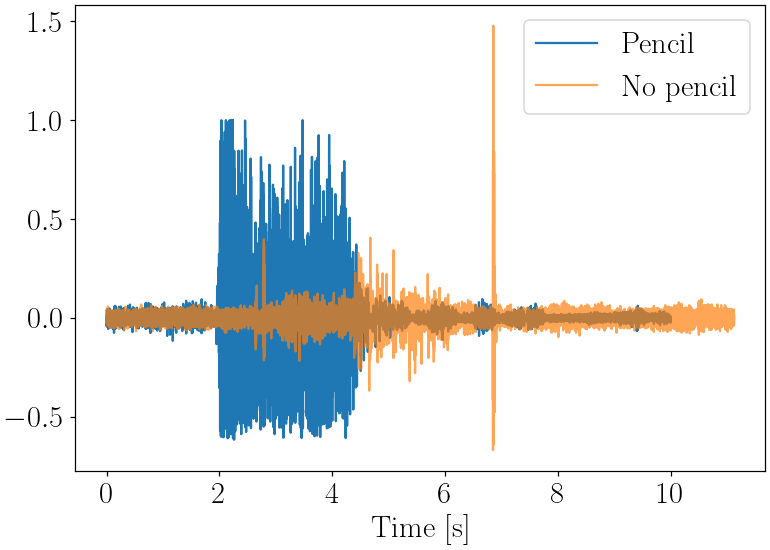

364
['fs 3700', 'frames_per_buffer None', 'samples_per_frame 100', 'refresh_rate_hz None']
Original data shape: (36300,)
Downsampled data shape: (36300,)
fs: 3635.2631339653553
rest_power: 0.000496212350644023
405
['fs 3700', 'frames_per_buffer None', 'samples_per_frame 100', 'refresh_rate_hz None']
Original data shape: (40400,)
Downsampled data shape: (40400,)
fs: 3635.7778539731225
rest_power: 4.167413543220185e-05


In [6]:
# 
#
#        laser pencil vs no pencil
#
#

%matplotlib notebook


fig = plt.figure(figsize=(7, 5), constrained_layout=True)
downsampling = 1

data_directory = "/home/idlab403/data/LaserMic"
file_name = 'pencil_laser.csv'

data, header, timestamps, time_axis = read_data(data_directory, file_name, downsampling)
mic_start_timestamp = datetime.strptime(timestamps[0], '%Y-%m-%d %H:%M:%S.%f')
time1 = datetime.strptime(timestamps[0], '%Y-%m-%d %H:%M:%S.%f')
time2 = datetime.strptime(timestamps[-1], '%Y-%m-%d %H:%M:%S.%f')
time_difference = (time2 - time1).total_seconds()
fs = len(data)/time_difference / downsampling
print(f'fs: {fs}')

data = np.clip(data - np.mean(data), -1, 1)
num_samples = 3600
rest_power = np.sum(np.array(data[0:num_samples])**2)/num_samples
power = np.sum(np.array(data)**2)/len(list(data))
print(f'rest_power: {rest_power}')

#plt.plot(time_axis, abs(data)/np.sqrt(rest_power))
plt.plot(time_axis, data, alpha=1)





downsampling = 1

data_directory = "/home/idlab403/data/LaserMic"
file_name = 'pencil_laser_moveOnly.csv'

data, header, timestamps, time_axis = read_data(data_directory, file_name, downsampling)
laser_start_timestamp = datetime.strptime(timestamps[0], '%Y-%m-%d %H:%M:%S.%f')
time1 = datetime.strptime(timestamps[0], '%Y-%m-%d %H:%M:%S.%f')
time2 = datetime.strptime(timestamps[-1], '%Y-%m-%d %H:%M:%S.%f')
time_difference = (time2 - time1).total_seconds()
fs = len(data)/time_difference / downsampling
print(f'fs: {fs}')

data = np.clip(data - np.mean(data), -1, 1)
num_samples = 3600
rest_power = np.sum(np.array(data[100:num_samples+100])**2)/num_samples
power = np.sum(np.array(data)**2)/len(list(data))
print(f'rest_power: {rest_power}')

plt.plot(time_axis, 3*data, alpha=0.7)



plt.xlabel('Time [s]')
#plt.ylim([-12, 12])
plt.legend(["Pencil", "No pencil"])
plt.show()



# Cable

<IPython.core.display.Javascript object>


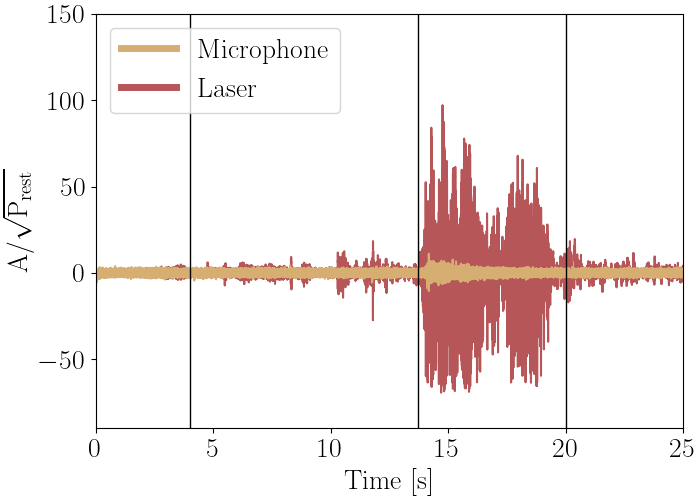

12191
['fs 3700', 'frames_per_buffer None', 'samples_per_frame 50', 'refresh_rate_hz None']
Original data shape: (609500,)
Downsampled data shape: (609500,)
fs: 20176.97741661595
start time: 2024-09-03 17:35:15.686527
MIC rest_power: 11251105.462562444 ; slip_power: 16617040.230501177 ; sensitivity: 1.2152880790652572
1040
['fs 3700', 'frames_per_buffer None', 'samples_per_frame 100', 'refresh_rate_hz None']
Original data shape: (103900,)
Downsampled data shape: (103900,)
fs: 3634.801838754943
start time: 2024-09-03 17:35:17.180996
LASER rest_power: 6.604649825072383e-05 ; slip_power: 0.025574755196992073 ; sensitivity: 19.677994932934716
-------------- Laser is 16.192041436027342 times more sensitive than mic


In [6]:
%matplotlib notebook

time_axis_offset = 0
fig = plt.figure(figsize=(7, 5), constrained_layout=True)




downsampling = 1

data_directory = "C:/Users/idlab403/data/LaserMic"
file_name = 'cable_mic4.csv'

data, header, timestamps, time_axis = read_data(data_directory, file_name, downsampling)
mic_time_axis = np.array(time_axis) - time_axis_offset
mic_start_timestamp = datetime.strptime(timestamps[0], '%Y-%m-%d %H:%M:%S.%f')
time1 = datetime.strptime(timestamps[0], '%Y-%m-%d %H:%M:%S.%f')
time2 = datetime.strptime(timestamps[-1], '%Y-%m-%d %H:%M:%S.%f')
time_difference = (time2 - time1).total_seconds()
fs = len(data)/time_difference / downsampling
print(f'fs: {fs}')
print(f'start time: {time1}')

mic_data = np.clip(data - np.mean(data), -300000, 300000)
num_samples = int(3*fs)
mic_rest_power = np.sum((np.array(mic_data[:num_samples]) - np.mean(mic_data[:num_samples]))**2)/num_samples
slip_range = [277000, 403500]
mic_slip_power = np.sum((np.array(mic_data[slip_range[0]:slip_range[1]]) - np.mean(mic_data[slip_range[0]:slip_range[1]]))**2)/(slip_range[1] - slip_range[0])
power = np.sum(np.array(mic_data)**2)/len(list(mic_data))
mic_sensitivity = np.sqrt(mic_slip_power/mic_rest_power)
print(f'MIC rest_power: {mic_rest_power} ; slip_power: {mic_slip_power} ; sensitivity: {mic_sensitivity}')





downsampling = 1

data_directory = "C:/Users/idlab403/data/LaserMic"
file_name = 'cable_laser4.csv'

data, header, timestamps, time_axis = read_data(data_directory, file_name, downsampling)
laser_start_timestamp = datetime.strptime(timestamps[0], '%Y-%m-%d %H:%M:%S.%f')
laser_time_axis = np.array(time_axis) + (laser_start_timestamp - mic_start_timestamp).total_seconds() - time_axis_offset
time1 = datetime.strptime(timestamps[0], '%Y-%m-%d %H:%M:%S.%f')
time2 = datetime.strptime(timestamps[-1], '%Y-%m-%d %H:%M:%S.%f')
time_difference = (time2 - time1).total_seconds()
fs = len(data)/time_difference / downsampling
print(f'fs: {fs}')
print(f'start time: {time1}')

laser_data = data - np.mean(data)
num_samples = int(3*fs)
laser_rest_power = np.sum((np.array(laser_data[:num_samples]) - np.mean(laser_data[:num_samples]))**2)/num_samples
slip_range = [45500, 67200]
laser_slip_power = np.sum((np.array(laser_data[slip_range[0]:slip_range[1]]) - np.mean(laser_data[slip_range[0]:slip_range[1]]))**2)/(slip_range[1] - slip_range[0])
power = np.sum(np.array(laser_data)**2)/len(list(laser_data))
laser_sensitivity = np.sqrt(laser_slip_power/laser_rest_power)
print(f'LASER rest_power: {laser_rest_power} ; slip_power: {laser_slip_power} ; sensitivity: {laser_sensitivity}')

print(f'-------------- Laser is {laser_sensitivity/mic_sensitivity} times more sensitive than mic')

plt.axvline(-10, linewidth=5, color=mic_color)
plt.axvline(-10, linewidth=5, color=laser_color)

plt.plot(laser_time_axis, laser_data/np.sqrt(laser_rest_power), alpha=1, color=laser_color)
plt.plot(mic_time_axis[::downsampling], mic_data/np.sqrt(mic_rest_power), alpha=1, color=mic_color)

plt.axvline(4-time_axis_offset, linewidth=1, color='black')
plt.axvline(13.7-time_axis_offset, linewidth=1, color='black')
plt.axvline(20-time_axis_offset, linewidth=1, color='black')

plt.xlim([time_axis[0] + time_axis_offset, 25])
plt.ylim([-90, 150])
plt.xlabel('Time [s]')
plt.ylabel('A/$\sqrt{\mathrm{P}_{\mathrm{rest}}}$')
#plt.ylim([-12, 12])
plt.legend(["Microphone", "Laser"])
plt.show()


#plt.savefig('cable_plot.svg')

In [ ]:
%matplotlib notebook
plt.plot(laser_data, alpha=1, color=laser_color)
plt.show()

In [ ]:
%matplotlib notebook
plt.plot(mic_data, alpha=1, color=laser_color)
plt.show()

<IPython.core.display.Javascript object>


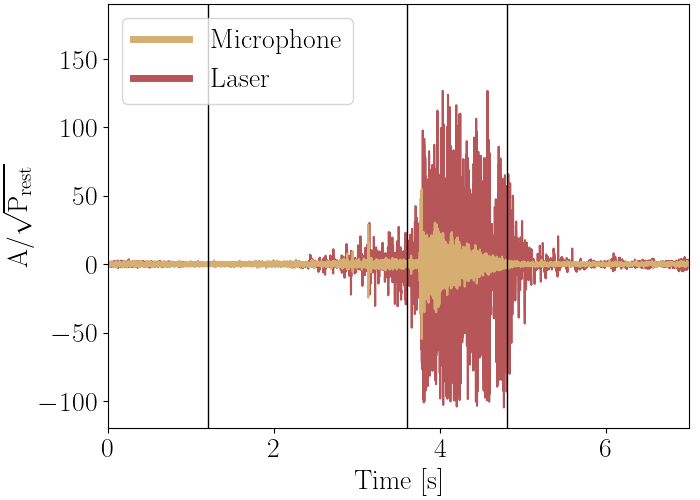

10300
['fs 3700', 'frames_per_buffer None', 'samples_per_frame 50', 'refresh_rate_hz None']
Original data shape: (514950,)
Downsampled data shape: (514950,)
fs: 19558.179973768227
start time: 2024-09-05 10:15:21.367906
MIC rest_power: 30066153.081549615 ; slip_power: 844155716.9622309 ; sensitivity: 5.29873683863531
895
['fs 3700', 'frames_per_buffer None', 'samples_per_frame 100', 'refresh_rate_hz None']
Original data shape: (89400,)
Downsampled data shape: (89400,)
fs: 3634.894006653401
start time: 2024-09-05 10:15:22.907694
LASER rest_power: 2.6506379677600534e-05 ; slip_power: 0.033361704796552656 ; sensitivity: 35.477165203227784
-------------- Laser is 6.695400485743868 times more sensitive than mic


In [7]:
%matplotlib notebook

time_axis_offset = 8
fig = plt.figure(figsize=(7, 5), constrained_layout=True)




downsampling = 1

data_directory = "C:/Users/idlab403/data/LaserMic"
file_name = 'cable_mic_fast2.csv'

data, header, timestamps, time_axis = read_data(data_directory, file_name, downsampling)
mic_time_axis = np.array(time_axis) - time_axis_offset
mic_start_timestamp = datetime.strptime(timestamps[0], '%Y-%m-%d %H:%M:%S.%f')
time1 = datetime.strptime(timestamps[0], '%Y-%m-%d %H:%M:%S.%f')
time2 = datetime.strptime(timestamps[-1], '%Y-%m-%d %H:%M:%S.%f')
time_difference = (time2 - time1).total_seconds()
fs = len(data)/time_difference / downsampling
print(f'fs: {fs}')
print(f'start time: {time1}')

mic_data = np.clip(data - np.mean(data), -300000, 300000)
num_samples = int(7*fs)
mic_rest_power = np.sum((np.array(mic_data[:num_samples]) - np.mean(mic_data[:num_samples]))**2)/num_samples
slip_range = [228000, 256000]
mic_slip_power = np.sum((np.array(mic_data[slip_range[0]:slip_range[1]]) - np.mean(mic_data[slip_range[0]:slip_range[1]]))**2)/(slip_range[1] - slip_range[0])
power = np.sum(np.array(mic_data)**2)/len(list(mic_data))
mic_sensitivity = np.sqrt(mic_slip_power/mic_rest_power)
print(f'MIC rest_power: {mic_rest_power} ; slip_power: {mic_slip_power} ; sensitivity: {mic_sensitivity}')





downsampling = 1

data_directory = "C:/Users/idlab403/data/LaserMic"
file_name = 'cable_laser_fast2.csv'

data, header, timestamps, time_axis = read_data(data_directory, file_name, downsampling)
laser_start_timestamp = datetime.strptime(timestamps[0], '%Y-%m-%d %H:%M:%S.%f')
laser_time_axis = np.array(time_axis) + (laser_start_timestamp - mic_start_timestamp).total_seconds() - time_axis_offset
time1 = datetime.strptime(timestamps[0], '%Y-%m-%d %H:%M:%S.%f')
time2 = datetime.strptime(timestamps[-1], '%Y-%m-%d %H:%M:%S.%f')
time_difference = (time2 - time1).total_seconds()
fs = len(data)/time_difference / downsampling
print(f'fs: {fs}')
print(f'start time: {time1}')

laser_data = data - np.mean(data)
num_samples = int(7*fs)
laser_rest_power = np.sum((np.array(laser_data[:num_samples]) - np.mean(laser_data[:num_samples]))**2)/num_samples
slip_range = [36000, 41000]
laser_slip_power = np.sum((np.array(laser_data[slip_range[0]:slip_range[1]]) - np.mean(laser_data[slip_range[0]:slip_range[1]]))**2)/(slip_range[1] - slip_range[0])
power = np.sum(np.array(laser_data)**2)/len(list(laser_data))
laser_sensitivity = np.sqrt(laser_slip_power/laser_rest_power)
print(f'LASER rest_power: {laser_rest_power} ; slip_power: {laser_slip_power} ; sensitivity: {laser_sensitivity}')

print(f'-------------- Laser is {laser_sensitivity/mic_sensitivity} times more sensitive than mic')

plt.axvline(-10, linewidth=5, color=mic_color)
plt.axvline(-10, linewidth=5, color=laser_color)

plt.plot(laser_time_axis, laser_data/np.sqrt(laser_rest_power), alpha=1, color=laser_color)
plt.plot(mic_time_axis[::downsampling], mic_data/np.sqrt(mic_rest_power), alpha=1, color=mic_color)

#plt.axvline(9-time_axis_offset, linewidth=1, color='black')
#plt.axvline(11-time_axis_offset, linewidth=1, color='black')
#plt.axvline(13-time_axis_offset, linewidth=1, color='black')
plt.axvline(10.2-1-time_axis_offset, linewidth=1, color='black')
plt.axvline(12.6-1-time_axis_offset, linewidth=1, color='black')
plt.axvline(13.8-1-time_axis_offset, linewidth=1, color='black')

plt.xlim([time_axis[0], 7])
#plt.ylim([-90, 150])
plt.xlabel('Time [s]')
plt.ylabel('A/$\sqrt{\mathrm{P}_{\mathrm{rest}}}$')
plt.ylim([-120, 190])
plt.legend(["Microphone", "Laser"])
plt.show()


plt.savefig('cable_plot_fast.svg')

<IPython.core.display.Javascript object>


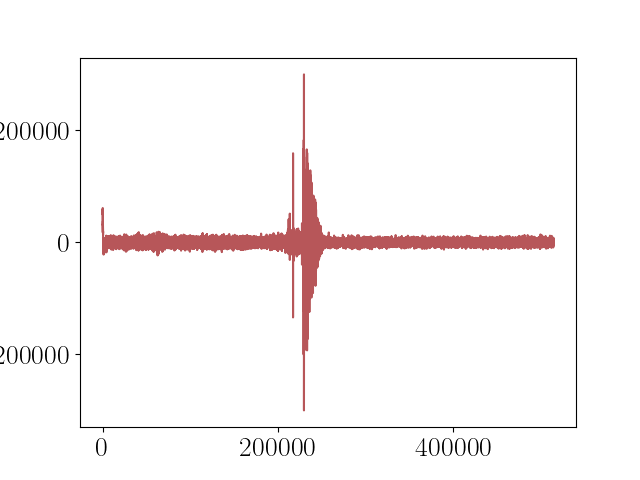

In [57]:
%matplotlib notebook
plt.plot(mic_data, alpha=1, color=laser_color)
plt.show()

# Box

<IPython.core.display.Javascript object>


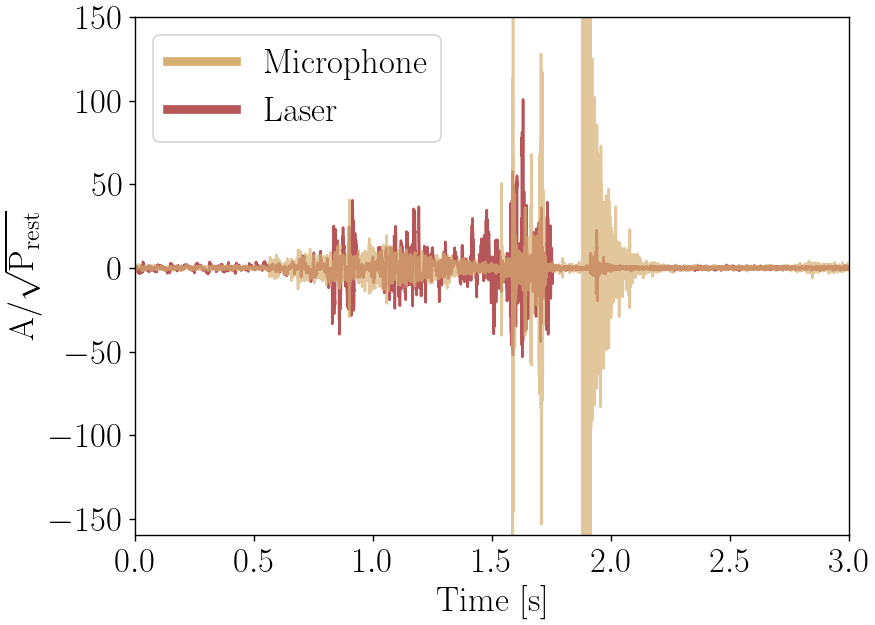

7991
['fs 3700', 'frames_per_buffer None', 'samples_per_frame 50', 'refresh_rate_hz None']
Original data shape: (399500,)
Downsampled data shape: (399500,)
fs: 19586.063861059847
MIC rest_power: 19825603.769932576 ; slip_power: 2116644251.1687477 ; sensitivity: 10.332626348241817
680
['fs 3700', 'frames_per_buffer None', 'samples_per_frame 100', 'refresh_rate_hz None']
Original data shape: (67900,)
Downsampled data shape: (67900,)
fs: 3634.7625694398907
LASER rest_power: 0.0001308326583633087 ; slip_power: 0.01777036173814008 ; sensitivity: 11.654403530475188
-------------- Laser is 1.1279226730634928 times more sensitive than mic
-------------- Mic is 0.8865856001315687 times more sensitive than laser


In [44]:
# 
#
#        Slow
#
#

%matplotlib notebook
time_axis_offset = 10

fig = plt.figure(figsize=(7, 5), constrained_layout=True)
downsampling = 1

data_directory = "C:/Users/idlab403/data/LaserMic"
file_name = 'box_mic.csv'

data, header, timestamps, time_axis = read_data(data_directory, file_name, downsampling)
mic_time_axis = np.array(time_axis) - time_axis_offset
mic_start_timestamp = datetime.strptime(timestamps[0], '%Y-%m-%d %H:%M:%S.%f')
time1 = datetime.strptime(timestamps[0], '%Y-%m-%d %H:%M:%S.%f')
time2 = datetime.strptime(timestamps[-1], '%Y-%m-%d %H:%M:%S.%f')
time_difference = (time2 - time1).total_seconds()
fs = len(data)/time_difference / downsampling
print(f'fs: {fs}')

mic_data = np.clip(data - np.mean(data), -40000000, 40000000)
num_samples = int(5*fs)
mic_rest_power = np.sum((np.array(mic_data[:num_samples]) - np.mean(mic_data[:num_samples]))**2)/num_samples
slip_range = [213000, 230000]
mic_slip_power = np.sum((np.array(mic_data[slip_range[0]:slip_range[1]]) - np.mean(mic_data[slip_range[0]:slip_range[1]]))**2)/(slip_range[1] - slip_range[0])
power = np.sum(np.array(mic_data)**2)/len(list(mic_data))
mic_sensitivity = np.sqrt(mic_slip_power/mic_rest_power)
print(f'MIC rest_power: {mic_rest_power} ; slip_power: {mic_slip_power} ; sensitivity: {mic_sensitivity}')






downsampling = 1

data_directory = "C:/Users/idlab403/data/LaserMic"
file_name = 'box_laser.csv'

data, header, timestamps, time_axis = read_data(data_directory, file_name, downsampling)
laser_start_timestamp = datetime.strptime(timestamps[0], '%Y-%m-%d %H:%M:%S.%f')
laser_time_axis = np.array(time_axis) + (laser_start_timestamp - mic_start_timestamp).total_seconds() - time_axis_offset
time1 = datetime.strptime(timestamps[0], '%Y-%m-%d %H:%M:%S.%f')
time2 = datetime.strptime(timestamps[-1], '%Y-%m-%d %H:%M:%S.%f')
time_difference = (time2 - time1).total_seconds()
fs = len(data)/time_difference / downsampling
print(f'fs: {fs}')

laser_data = data - np.mean(data)
num_samples = int(5*fs)
laser_rest_power = np.sum((np.array(laser_data[:num_samples]) - np.mean(laser_data[:num_samples]))**2)/num_samples
laser_slip_range = [33700, 36850]
laser_slip_power = np.sum((np.array(laser_data[laser_slip_range[0]:laser_slip_range[1]]) - np.mean(laser_data[laser_slip_range[0]:laser_slip_range[1]]))**2)/(laser_slip_range[1] - laser_slip_range[0])
power = np.sum(np.array(laser_data)**2)/len(list(laser_data))
laser_sensitivity = np.sqrt(laser_slip_power/laser_rest_power)
print(f'LASER rest_power: {laser_rest_power} ; slip_power: {laser_slip_power} ; sensitivity: {laser_sensitivity}')

print(f'-------------- Laser is {laser_sensitivity/mic_sensitivity} times more sensitive than mic')
print(f'-------------- Mic is {mic_sensitivity/laser_sensitivity} times more sensitive than laser')



plt.axvline(-10, linewidth=5, color=mic_color)
plt.axvline(-10, linewidth=5, color=laser_color)
plt.plot(laser_time_axis, laser_data/np.sqrt(laser_rest_power), alpha=1, color=laser_color)
plt.plot(mic_time_axis, mic_data/np.sqrt(mic_rest_power), alpha=0.7, color=mic_color)

'''plt.axvline(laser_time_axis[laser_slip_range[0]], linewidth=1, color='black')
plt.axvline(laser_time_axis[laser_slip_range[1]], linewidth=1, color='black')
plt.axvline(mic_time_axis[slip_range[0]], linewidth=1, color='black')
plt.axvline(mic_time_axis[slip_range[1]], linewidth=1, color='black')'''

plt.xlim([0, 3])
plt.xlabel('Time [s]')
plt.ylabel('A/$\sqrt{\mathrm{P}_{\mathrm{rest}}}$')
plt.ylim([-160, 150])
plt.legend(["Microphone", "Laser"])
plt.show()

plt.savefig('box_plot.svg')

In [30]:
%matplotlib notebook
plt.plot(mic_data, alpha=1, color=laser_color)
plt.xlim([200000, 246000])
plt.show()

In [45]:
print(f'mic: {mic_time_axis[slip_range[0]]} - laser: {laser_time_axis[laser_slip_range[0]]}')
print(f'mic: {mic_time_axis[slip_range[1]]} - laser: {laser_time_axis[laser_slip_range[1]]}')

mic: 0.8018739999999998 - laser: 0.8058680000000003
mic: 1.6823949999999996 - laser: 1.6720825000000001


<IPython.core.display.Javascript object>


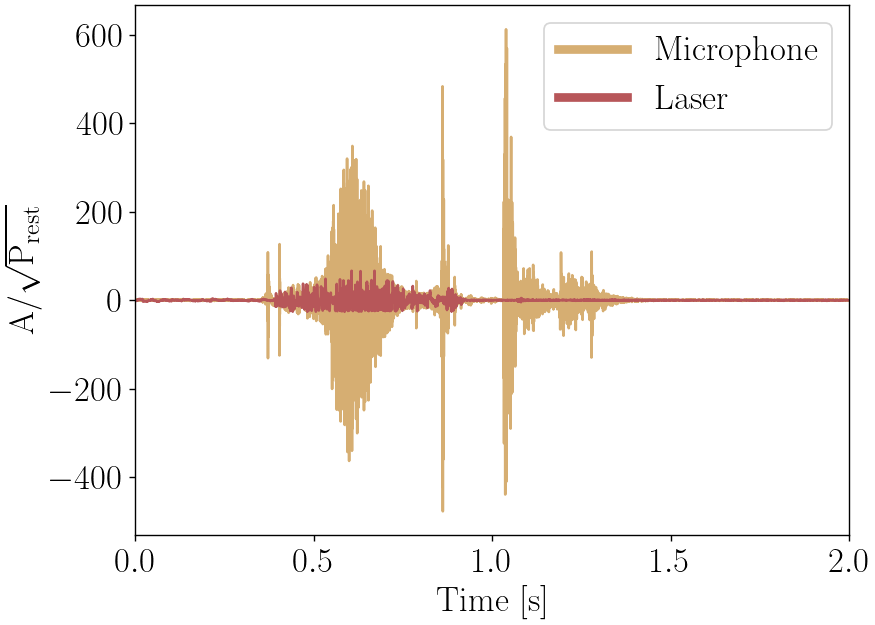

7874
['fs 3700', 'frames_per_buffer None', 'samples_per_frame 50', 'refresh_rate_hz None']
Original data shape: (393650,)
Downsampled data shape: (393650,)
fs: 19425.99335593029
MIC rest_power: 27187791.972420506 ; slip_power: 97309689140.71974 ; sensitivity: 59.82615247062203
675
['fs 3700', 'frames_per_buffer None', 'samples_per_frame 100', 'refresh_rate_hz None']
Original data shape: (67400,)
Downsampled data shape: (67400,)
fs: 3635.051409280847
LASER rest_power: 0.0005285597505215578 ; slip_power: 0.12726718584948685 ; sensitivity: 15.51712205066497
-------------- Laser is 0.2593702153633353 times more sensitive than mic
-------------- Mic is 3.8554928082207254 times more sensitive than laser


In [60]:
# 
#
#        Fast
#
#

%matplotlib notebook
time_axis_offset = 8.5

fig = plt.figure(figsize=(7, 5), constrained_layout=True)
downsampling = 1

data_directory = "C:/Users/idlab403/data/LaserMic"
file_name = 'box_mic2.csv'

data, header, timestamps, time_axis = read_data(data_directory, file_name, downsampling)
mic_time_axis = np.array(time_axis) - time_axis_offset
mic_start_timestamp = datetime.strptime(timestamps[0], '%Y-%m-%d %H:%M:%S.%f')
time1 = datetime.strptime(timestamps[0], '%Y-%m-%d %H:%M:%S.%f')
time2 = datetime.strptime(timestamps[-1], '%Y-%m-%d %H:%M:%S.%f')
time_difference = (time2 - time1).total_seconds()
fs = len(data)/time_difference / downsampling
print(f'fs: {fs}')

mic_data = np.clip(data - np.mean(data), -40000000, 40000000)
num_samples = int(3*fs)
mic_rest_power = np.sum((np.array(mic_data[:num_samples]) - np.mean(mic_data[:num_samples]))**2)/num_samples
slip_range = [173500, 181500]
mic_slip_power = np.sum((np.array(mic_data[slip_range[0]:slip_range[1]]) - np.mean(mic_data[slip_range[0]:slip_range[1]]))**2)/(slip_range[1] - slip_range[0])
power = np.sum(np.array(mic_data)**2)/len(list(mic_data))
mic_sensitivity = np.sqrt(mic_slip_power/mic_rest_power)
print(f'MIC rest_power: {mic_rest_power} ; slip_power: {mic_slip_power} ; sensitivity: {mic_sensitivity}')






downsampling = 1

data_directory = "C:/Users/idlab403/data/LaserMic"
file_name = 'box_laser2.csv'

data, header, timestamps, time_axis = read_data(data_directory, file_name, downsampling)
laser_start_timestamp = datetime.strptime(timestamps[0], '%Y-%m-%d %H:%M:%S.%f')
laser_time_axis = np.array(time_axis) + (laser_start_timestamp - mic_start_timestamp).total_seconds() - time_axis_offset
time1 = datetime.strptime(timestamps[0], '%Y-%m-%d %H:%M:%S.%f')
time2 = datetime.strptime(timestamps[-1], '%Y-%m-%d %H:%M:%S.%f')
time_difference = (time2 - time1).total_seconds()
fs = len(data)/time_difference / downsampling
print(f'fs: {fs}')

laser_data = data - np.mean(data)
num_samples = int(3*fs)
laser_rest_power = np.sum((np.array(laser_data[:num_samples]) - np.mean(laser_data[:num_samples]))**2)/num_samples
laser_slip_range = [26750, 28350]
laser_slip_power = np.sum((np.array(laser_data[laser_slip_range[0]:laser_slip_range[1]]) - np.mean(laser_data[laser_slip_range[0]:laser_slip_range[1]]))**2)/(laser_slip_range[1] - laser_slip_range[0])
power = np.sum(np.array(laser_data)**2)/len(list(laser_data))
laser_sensitivity = np.sqrt(laser_slip_power/laser_rest_power)
print(f'LASER rest_power: {laser_rest_power} ; slip_power: {laser_slip_power} ; sensitivity: {laser_sensitivity}')

print(f'-------------- Laser is {laser_sensitivity/mic_sensitivity} times more sensitive than mic')
print(f'-------------- Mic is {mic_sensitivity/laser_sensitivity} times more sensitive than laser')



plt.axvline(-10, linewidth=5, color=mic_color)
plt.axvline(-10, linewidth=5, color=laser_color)
plt.plot(mic_time_axis, mic_data/np.sqrt(mic_rest_power), alpha=1, color=mic_color)
plt.plot(laser_time_axis, laser_data/np.sqrt(laser_rest_power), alpha=1, color=laser_color)

'''plt.axvline(laser_time_axis[laser_slip_range[0]], linewidth=1, color='black')
plt.axvline(laser_time_axis[laser_slip_range[1]], linewidth=1, color='black')
plt.axvline(mic_time_axis[slip_range[0]], linewidth=1, color='black')
plt.axvline(mic_time_axis[slip_range[1]], linewidth=1, color='black')'''

plt.xlim([0, 2])
plt.xlabel('Time [s]')
plt.ylabel('A/$\sqrt{\mathrm{P}_{\mathrm{rest}}}$')
#plt.ylim([-400, 400])
plt.legend(["Microphone", "Laser"])
plt.show()

#plt.savefig('box_plot_fast.svg')

<IPython.core.display.Javascript object>


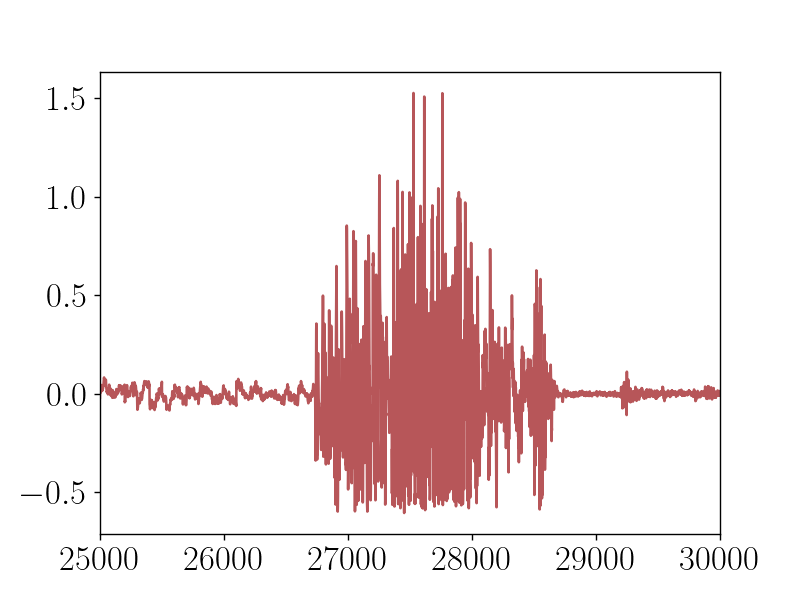

In [57]:
%matplotlib notebook
plt.plot(laser_data, alpha=1, color=laser_color)
plt.xlim([25000, 30000])
plt.show()

In [61]:
print(f'mic: {mic_time_axis[slip_range[0]]} - laser: {laser_time_axis[laser_slip_range[0]]}')
print(f'mic: {mic_time_axis[slip_range[1]]} - laser: {laser_time_axis[laser_slip_range[1]]}')

mic: 0.40945699999999974 - laser: 0.39493249999999946
mic: 0.830527 - laser: 0.8330815000000005


# TMP

815
['fs 3700', 'frames_per_buffer None', 'samples_per_frame 100', 'refresh_rate_hz None']
Original data shape: (81400,)
Downsampled data shape: (81400,)
fs: 3635.2672910662504
LASER rest_power: 1.6313574244877386e-06 ; slip_power: 6.57305121421814e-06 ; sensitivity: 2.007284569837502


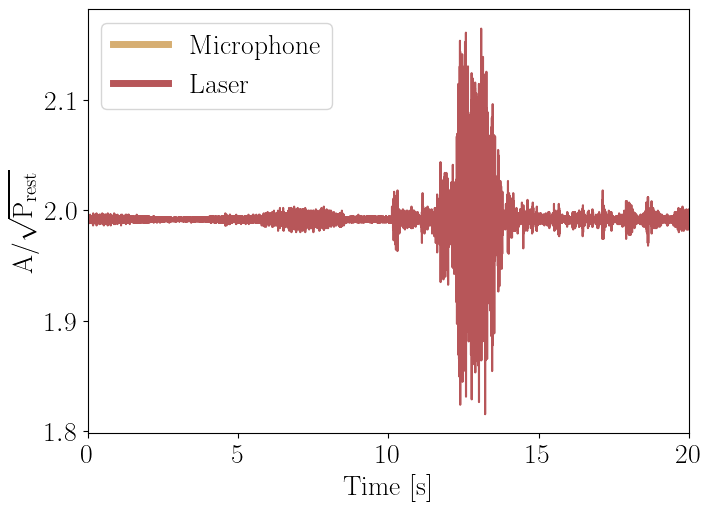

In [8]:
%matplotlib inline
time_axis_offset = 2

fig = plt.figure(figsize=(7, 5), constrained_layout=True)
downsampling = 1

data_directory = "/home/idlab403/data/LaserMic"
file_name = 'cable_laser_fast.csv'

data, header, timestamps, time_axis = read_data(data_directory, file_name, downsampling)
laser_start_timestamp = datetime.strptime(timestamps[0], '%Y-%m-%d %H:%M:%S.%f')
laser_time_axis = np.array(time_axis)
time1 = datetime.strptime(timestamps[0], '%Y-%m-%d %H:%M:%S.%f')
time2 = datetime.strptime(timestamps[-1], '%Y-%m-%d %H:%M:%S.%f')
time_difference = (time2 - time1).total_seconds()
fs = len(data)/time_difference / downsampling
print(f'fs: {fs}')

laser_data = data
num_samples = int(4*fs)
laser_rest_power = np.sum((np.array(laser_data[:num_samples]) - np.mean(laser_data[:num_samples]))**2)/num_samples
slip_range = [25000, 36000]
laser_slip_power = np.sum((np.array(laser_data[slip_range[0]:slip_range[1]]) - np.mean(laser_data[slip_range[0]:slip_range[1]]))**2)/(slip_range[1] - slip_range[0])
power = np.sum(np.array(laser_data)**2)/len(list(laser_data))
laser_sensitivity = np.sqrt(laser_slip_power/laser_rest_power)
print(f'LASER rest_power: {laser_rest_power} ; slip_power: {laser_slip_power} ; sensitivity: {laser_sensitivity}')



plt.axvline(-10, linewidth=5, color=mic_color)
plt.axvline(-10, linewidth=5, color=laser_color)
plt.plot(laser_time_axis, laser_data, alpha=1, color=laser_color)


plt.xlim([0, 20])
#plt.ylim([-10, 10])
plt.xlabel('Time [s]')
plt.ylabel('A/$\sqrt{\mathrm{P}_{\mathrm{rest}}}$')
#plt.ylim([-12, 12])
plt.legend(["Microphone", "Laser"])
plt.show()